Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detected dog with confidence 0.979 at [38.28, 34.61, 171.33, 120.56]
Detected cat with confidence 0.969 at [163.16, 38.33, 246.16, 118.71]


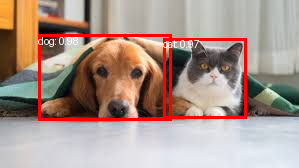

In [2]:
#object detection
import torch
from transformers import DetrImageProcessor, DetrForObjectDetection
from PIL import Image, ImageDraw, ImageFont
import requests

# 1. Load the "Processor" and "Model"
# Processor: Handles resizing/normalizing pixels
# Model: The DETR brain that predicts boxes
model_id = "facebook/detr-resnet-50"
processor = DetrImageProcessor.from_pretrained(model_id)
model = DetrForObjectDetection.from_pretrained(model_id)

def detect_and_draw(image_url):
    # Load image with headers (to avoid the 403 error we saw earlier)
    headers = {'User-Agent': 'Mozilla/5.0'}
    image = Image.open(requests.get(image_url, stream=True, headers=headers).raw)

    # 2. Pre-process the image
    inputs = processor(images=image, return_tensors="pt")

    # 3. Forward Pass (Inference)
    outputs = model(**inputs)

    # 4. Post-Process: Convert raw data into real pixel coordinates
    # We only keep detections with a confidence score > 0.9
    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]

    # 5. Drawing the "Bounding Boxes"
    draw = ImageDraw.Draw(image)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        name = model.config.id2label[label.item()]

        # Draw the rectangle [xmin, ymin, xmax, ymax]
        draw.rectangle(box, outline="red", width=3)

        # Draw the label text
        draw.text((box[0], box[1]), f"{name}: {round(score.item(), 2)}", fill="white")

        print(f"Detected {name} with confidence {round(score.item(), 3)} at {box}")

    return image

# --- Run it ---
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQJiY0A4PgCKivjQnYz6BDHM5SHNt0l5uXY5A&s"
output_image = detect_and_draw(url)
output_image # In Colab, just type 'output_image' to see it